Data path: /Users/sreeragm/fraud-decision-engine/data/creditcard.csv
Reports path: /Users/sreeragm/fraud-decision-engine/reports

Dataset shape: (284807, 31)
Fraud count: 492
Non-fraud count: 284315

Temporal split:
Train: (199364, 31)
Validation: (42721, 31)
Test: (42722, 31)

Fraud counts:
Train fraud: 384
Validation fraud: 56
Test fraud: 52

Class weighting:
Negative: 198980
Positive: 384
scale_pos_weight: 518.1770833333334

Training XGBoost...
XGBoost training complete.

RAW XGBOOST PERFORMANCE
Validation PR-AUC  : 0.861824
Test PR-AUC        : 0.768413
Validation ROC-AUC : 0.988541
Test ROC-AUC       : 0.979666
Validation Brier   : 0.000329
Test Brier         : 0.000417

FITTING ISOTONIC CALIBRATION
Calibration complete.

RAW VS CALIBRATED

VALIDATION
----------------------------------------
Raw PR-AUC         : 0.861824
Calibrated PR-AUC  : 0.860722
Raw ROC-AUC        : 0.988541
Calibrated ROC-AUC : 0.991105
Raw Brier          : 0.000329
Calibrated Brier   : 0.000290

TEST
------

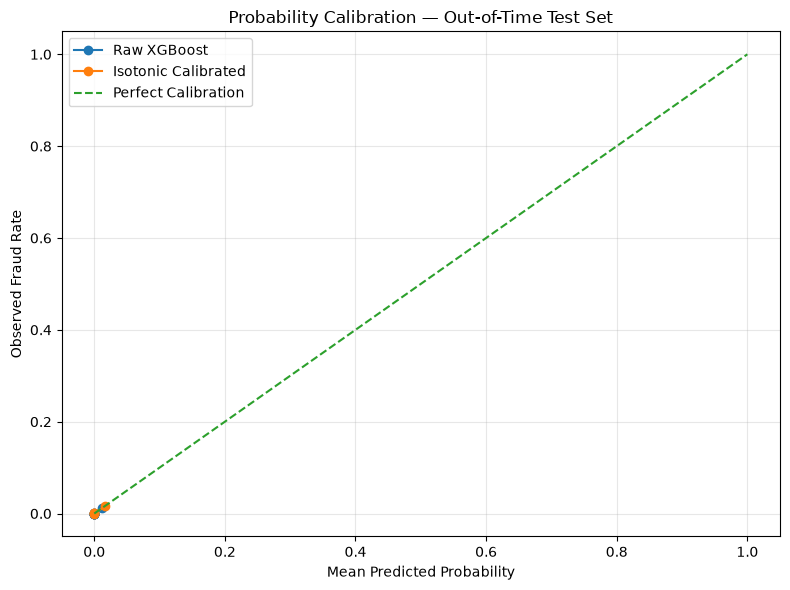

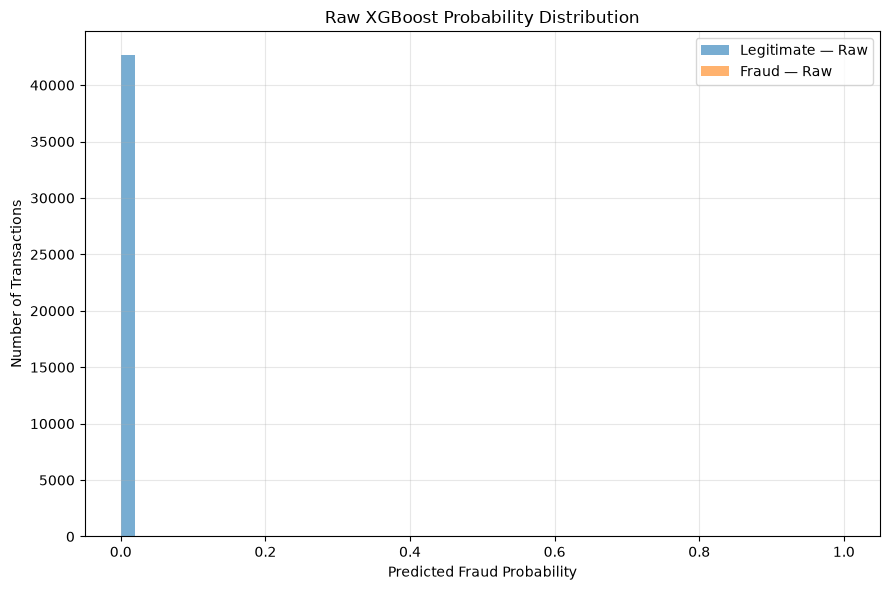


SHAP EXPLAINABILITY

Creating SHAP TreeExplainer...
Calculating SHAP values for 5000 test transactions...
SHAP calculation complete.


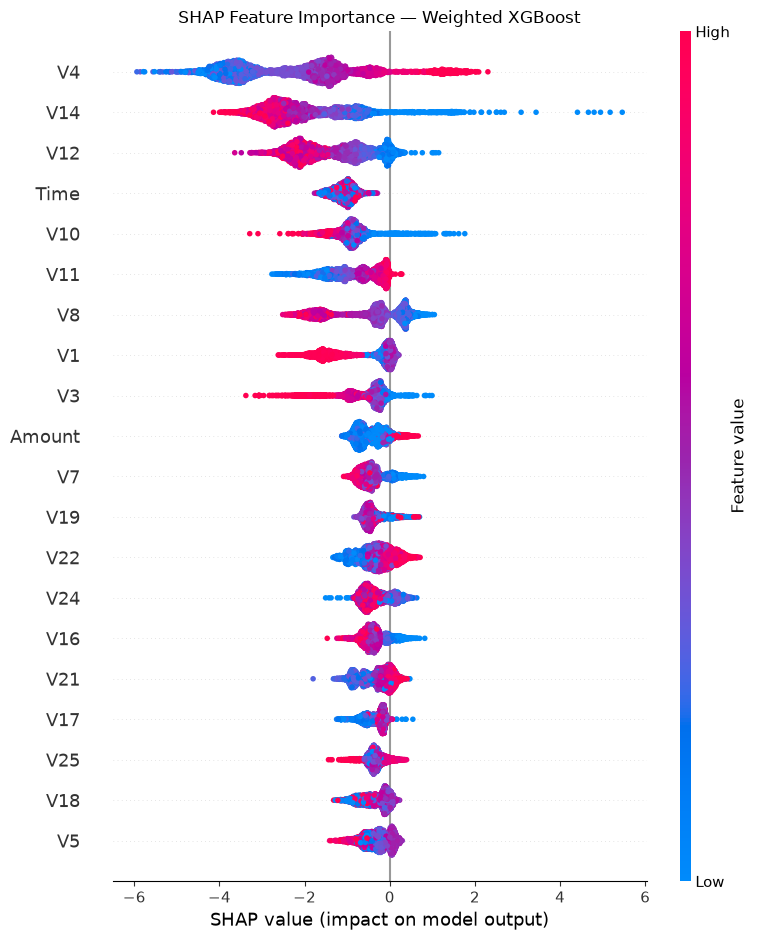


TOP 20 SHAP FEATURES
Feature  Mean_Absolute_SHAP
     V4            2.381419
    V14            2.080100
    V12            1.334814
   Time            1.072447
    V10            0.947519
    V11            0.807010
     V8            0.742615
     V1            0.680644
     V3            0.548424
 Amount            0.473924
     V7            0.471298
    V19            0.425284
    V22            0.403588
    V24            0.394682
    V16            0.394154
    V21            0.364499
    V17            0.360248
    V25            0.349429
    V18            0.347983
     V5            0.332469

Saved: ../reports/shap_feature_importance.csv


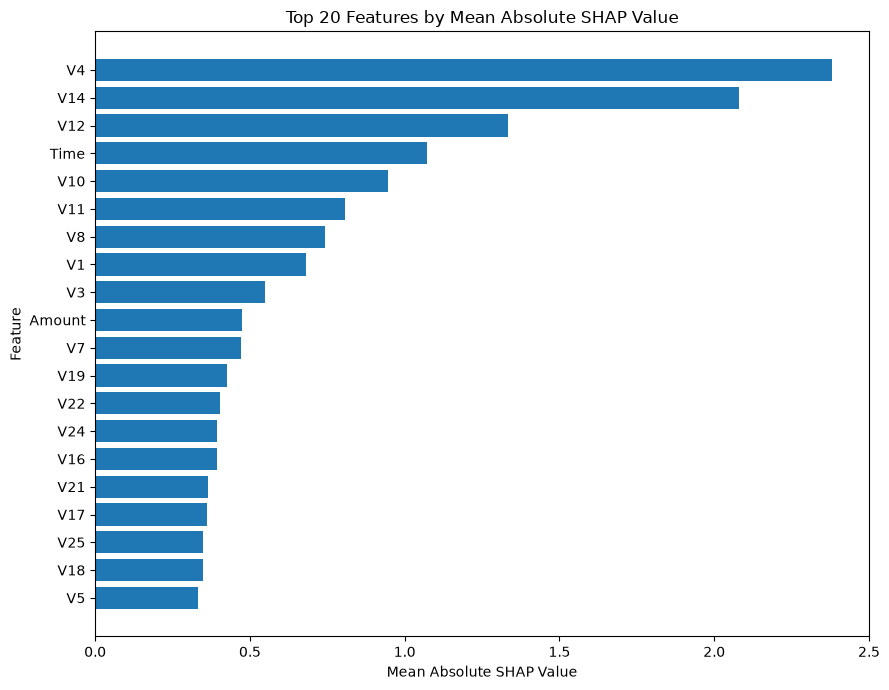


HIGHEST-RISK TEST TRANSACTION

Original row index : 243393
Calibrated fraud probability : 1.000000
Actual class : 1

Highest-risk transaction was not included in the SHAP sample.
This is expected because SHAP uses a random sample of up to 5,000 test transactions.

Saved: ../reports/phase7_summary.json


PHASE 7 COMPLETE

Generated reports:
✓ calibration_results.csv
✓ calibration_curve.png
✓ raw_probability_distribution.png
✓ shap_feature_importance.csv
✓ shap_summary.png
✓ shap_feature_importance_bar.png
— highest_risk_shap_waterfall.png (not generated)
— highest_risk_transaction_shap.csv (not generated)
✓ phase7_summary.json

Next step: Phase 8 — SMOTE vs Class Weighting


In [2]:
# ============================================================
# PHASE 7 — PROBABILITY CALIBRATION + SHAP EXPLAINABILITY
# Credit Card Fraud Decision Engine
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    precision_recall_curve,
)
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier
import shap


# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = Path("../data/creditcard.csv")
REPORTS_PATH = Path("../reports")

REPORTS_PATH.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH.resolve())
print("Reports path:", REPORTS_PATH.resolve())


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

print("\nDataset shape:", df.shape)
print("Fraud count:", df["Class"].sum())
print("Non-fraud count:", (df["Class"] == 0).sum())


# ============================================================
# 3. SORT CHRONOLOGICALLY
# ============================================================

df = df.sort_values("Time").reset_index(drop=True)


# ============================================================
# 4. TEMPORAL 70 / 15 / 15 SPLIT
# ============================================================

n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
validation = df.iloc[train_end:validation_end].copy()
test = df.iloc[validation_end:].copy()

print("\nTemporal split:")
print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

print("\nFraud counts:")
print("Train fraud:", train["Class"].sum())
print("Validation fraud:", validation["Class"].sum())
print("Test fraud:", test["Class"].sum())


# ============================================================
# 5. FEATURES / TARGET
# ============================================================

X_train = train.drop(columns=["Class"])
y_train = train["Class"]

X_validation = validation.drop(columns=["Class"])
y_validation = validation["Class"]

X_test = test.drop(columns=["Class"])
y_test = test["Class"]


# ============================================================
# 6. CLASS WEIGHT
# ============================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("\nClass weighting:")
print("Negative:", negative_count)
print("Positive:", positive_count)
print("scale_pos_weight:", scale_pos_weight)


# ============================================================
# 7. TRAIN WEIGHTED XGBOOST
# ============================================================

base_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="aucpr",

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("\nTraining XGBoost...")

base_model.fit(
    X_train,
    y_train
)

print("XGBoost training complete.")


# ============================================================
# 8. RAW XGBOOST PROBABILITIES
# ============================================================

validation_raw_prob = base_model.predict_proba(
    X_validation
)[:, 1]

test_raw_prob = base_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 9. RAW MODEL METRICS
# ============================================================

validation_raw_pr_auc = average_precision_score(
    y_validation,
    validation_raw_prob
)

test_raw_pr_auc = average_precision_score(
    y_test,
    test_raw_prob
)

validation_raw_roc_auc = roc_auc_score(
    y_validation,
    validation_raw_prob
)

test_raw_roc_auc = roc_auc_score(
    y_test,
    test_raw_prob
)

validation_raw_brier = brier_score_loss(
    y_validation,
    validation_raw_prob
)

test_raw_brier = brier_score_loss(
    y_test,
    test_raw_prob
)


print("\n" + "=" * 60)
print("RAW XGBOOST PERFORMANCE")
print("=" * 60)

print(f"Validation PR-AUC  : {validation_raw_pr_auc:.6f}")
print(f"Test PR-AUC        : {test_raw_pr_auc:.6f}")

print(f"Validation ROC-AUC : {validation_raw_roc_auc:.6f}")
print(f"Test ROC-AUC       : {test_raw_roc_auc:.6f}")

print(f"Validation Brier   : {validation_raw_brier:.6f}")
print(f"Test Brier         : {test_raw_brier:.6f}")


# ============================================================
# 10. PROBABILITY CALIBRATION
#
# IMPORTANT:
# We DO NOT use:
#
# CalibratedClassifierCV(..., cv="prefit")
#
# because sklearn 1.9.1 no longer accepts cv="prefit".
#
# Instead, we explicitly fit an IsotonicRegression mapping
# using validation predictions.
#
# Test data remains untouched until final evaluation.
# ============================================================

print("\n" + "=" * 60)
print("FITTING ISOTONIC CALIBRATION")
print("=" * 60)

calibrator = IsotonicRegression(
    y_min=0,
    y_max=1,
    out_of_bounds="clip"
)

calibrator.fit(
    validation_raw_prob,
    y_validation
)

validation_calibrated_prob = calibrator.predict(
    validation_raw_prob
)

test_calibrated_prob = calibrator.predict(
    test_raw_prob
)

print("Calibration complete.")


# ============================================================
# 11. CALIBRATED METRICS
# ============================================================

validation_cal_pr_auc = average_precision_score(
    y_validation,
    validation_calibrated_prob
)

test_cal_pr_auc = average_precision_score(
    y_test,
    test_calibrated_prob
)

validation_cal_roc_auc = roc_auc_score(
    y_validation,
    validation_calibrated_prob
)

test_cal_roc_auc = roc_auc_score(
    y_test,
    test_calibrated_prob
)

validation_cal_brier = brier_score_loss(
    y_validation,
    validation_calibrated_prob
)

test_cal_brier = brier_score_loss(
    y_test,
    test_calibrated_prob
)


# ============================================================
# 12. CALIBRATION COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("RAW VS CALIBRATED")
print("=" * 60)

print("\nVALIDATION")
print("-" * 40)

print(
    f"Raw PR-AUC         : {validation_raw_pr_auc:.6f}"
)

print(
    f"Calibrated PR-AUC  : {validation_cal_pr_auc:.6f}"
)

print(
    f"Raw ROC-AUC        : {validation_raw_roc_auc:.6f}"
)

print(
    f"Calibrated ROC-AUC : {validation_cal_roc_auc:.6f}"
)

print(
    f"Raw Brier          : {validation_raw_brier:.6f}"
)

print(
    f"Calibrated Brier   : {validation_cal_brier:.6f}"
)


print("\nTEST")
print("-" * 40)

print(
    f"Raw PR-AUC         : {test_raw_pr_auc:.6f}"
)

print(
    f"Calibrated PR-AUC  : {test_cal_pr_auc:.6f}"
)

print(
    f"Raw ROC-AUC        : {test_raw_roc_auc:.6f}"
)

print(
    f"Calibrated ROC-AUC : {test_cal_roc_auc:.6f}"
)

print(
    f"Raw Brier          : {test_raw_brier:.6f}"
)

print(
    f"Calibrated Brier   : {test_cal_brier:.6f}"
)


# ============================================================
# 13. SAVE CALIBRATION RESULTS
# ============================================================

calibration_results = pd.DataFrame({
    "Dataset": [
        "Validation",
        "Validation",
        "Test",
        "Test"
    ],

    "Model": [
        "Raw XGBoost",
        "Isotonic Calibrated",
        "Raw XGBoost",
        "Isotonic Calibrated"
    ],

    "PR_AUC": [
        validation_raw_pr_auc,
        validation_cal_pr_auc,
        test_raw_pr_auc,
        test_cal_pr_auc
    ],

    "ROC_AUC": [
        validation_raw_roc_auc,
        validation_cal_roc_auc,
        test_raw_roc_auc,
        test_cal_roc_auc
    ],

    "Brier_Score": [
        validation_raw_brier,
        validation_cal_brier,
        test_raw_brier,
        test_cal_brier
    ]
})

calibration_results.to_csv(
    REPORTS_PATH / "calibration_results.csv",
    index=False
)

print(
    "\nSaved:",
    REPORTS_PATH / "calibration_results.csv"
)


# ============================================================
# 14. RELIABILITY / CALIBRATION CURVE
# ============================================================

print("\nGenerating calibration curve...")

fraction_pos_raw, mean_pred_raw = calibration_curve(
    y_test,
    test_raw_prob,
    n_bins=10,
    strategy="quantile"
)

fraction_pos_cal, mean_pred_cal = calibration_curve(
    y_test,
    test_calibrated_prob,
    n_bins=10,
    strategy="quantile"
)


plt.figure(figsize=(8, 6))

plt.plot(
    mean_pred_raw,
    fraction_pos_raw,
    marker="o",
    label="Raw XGBoost"
)

plt.plot(
    mean_pred_cal,
    fraction_pos_cal,
    marker="o",
    label="Isotonic Calibrated"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraud Rate")

plt.title("Probability Calibration — Out-of-Time Test Set")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH / "calibration_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. PREDICTED PROBABILITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

plt.hist(
    test_raw_prob[y_test.values == 0],
    bins=50,
    alpha=0.6,
    label="Legitimate — Raw"
)

plt.hist(
    test_raw_prob[y_test.values == 1],
    bins=50,
    alpha=0.6,
    label="Fraud — Raw"
)

plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Number of Transactions")

plt.title("Raw XGBoost Probability Distribution")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH / "raw_probability_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. SHAP EXPLAINABILITY
# ============================================================

print("\n" + "=" * 60)
print("SHAP EXPLAINABILITY")
print("=" * 60)

print("\nCreating SHAP TreeExplainer...")

explainer = shap.TreeExplainer(base_model)

# Limit SHAP sample size for speed
shap_sample_size = min(
    5000,
    len(X_test)
)

X_shap = X_test.sample(
    n=shap_sample_size,
    random_state=42
)

print(
    f"Calculating SHAP values for {shap_sample_size} test transactions..."
)

shap_values = explainer(
    X_shap
)

print("SHAP calculation complete.")


# ============================================================
# 17. SHAP SUMMARY PLOT
# ============================================================

plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    show=False,
    max_display=20
)

plt.title(
    "SHAP Feature Importance — Weighted XGBoost"
)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH / "shap_summary.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. MEAN ABSOLUTE SHAP IMPORTANCE
# ============================================================

mean_abs_shap = np.abs(
    shap_values.values
).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 60)
print("TOP 20 SHAP FEATURES")
print("=" * 60)

print(
    shap_importance.head(20).to_string(index=False)
)


# ============================================================
# 19. SAVE SHAP FEATURE IMPORTANCE
# ============================================================

shap_importance.to_csv(
    REPORTS_PATH / "shap_feature_importance.csv",
    index=False
)

print(
    "\nSaved:",
    REPORTS_PATH / "shap_feature_importance.csv"
)


# ============================================================
# 20. SHAP BAR PLOT
# ============================================================

plt.figure(figsize=(9, 7))

top_features = shap_importance.head(20).sort_values(
    "Mean_Absolute_SHAP"
)

plt.barh(
    top_features["Feature"],
    top_features["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")

plt.ylabel("Feature")

plt.title(
    "Top 20 Features by Mean Absolute SHAP Value"
)

plt.tight_layout()

plt.savefig(
    REPORTS_PATH / "shap_feature_importance_bar.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. FIND HIGHEST-RISK TEST TRANSACTION
# ============================================================

highest_risk_position = np.argmax(
    test_calibrated_prob
)

highest_risk_index = X_test.index[
    highest_risk_position
]

highest_risk_probability = test_calibrated_prob[
    highest_risk_position
]

highest_risk_actual_class = y_test.iloc[
    highest_risk_position
]

highest_risk_row = X_test.loc[
    highest_risk_index
]


print("\n" + "=" * 60)
print("HIGHEST-RISK TEST TRANSACTION")
print("=" * 60)

print(
    f"\nOriginal row index : {highest_risk_index}"
)

print(
    f"Calibrated fraud probability : "
    f"{highest_risk_probability:.6f}"
)

print(
    f"Actual class : "
    f"{highest_risk_actual_class}"
)


# ============================================================
# 22. SHAP WATERFALL FOR HIGHEST-RISK TRANSACTION
# ============================================================

highest_risk_shap_position = np.where(
    X_shap.index == highest_risk_index
)[0]

if len(highest_risk_shap_position) > 0:

    position = highest_risk_shap_position[0]

    print(
        "\nGenerating SHAP waterfall for highest-risk "
        "transaction..."
    )

    shap.plots.waterfall(
        shap_values[position],
        max_display=15,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        REPORTS_PATH / "highest_risk_shap_waterfall.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

else:

    print(
        "\nHighest-risk transaction was not included "
        "in the SHAP sample."
    )

    print(
        "This is expected because SHAP uses a random "
        "sample of up to 5,000 test transactions."
    )


# ============================================================
# 23. TOP SHAP FEATURES FOR HIGHEST-RISK TRANSACTION
# ============================================================

if len(highest_risk_shap_position) > 0:

    position = highest_risk_shap_position[0]

    individual_shap = pd.DataFrame({
        "Feature": X_shap.columns,
        "Feature_Value": X_shap.iloc[position].values,
        "SHAP_Value": shap_values.values[position]
    })

    individual_shap["Absolute_SHAP"] = (
        individual_shap["SHAP_Value"].abs()
    )

    individual_shap = individual_shap.sort_values(
        "Absolute_SHAP",
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 60)
    print("TOP SHAP DRIVERS — HIGHEST-RISK TRANSACTION")
    print("=" * 60)

    print(
        individual_shap.head(15).to_string(index=False)
    )

    individual_shap.to_csv(
        REPORTS_PATH / "highest_risk_transaction_shap.csv",
        index=False
    )

    print(
        "\nSaved:",
        REPORTS_PATH /
        "highest_risk_transaction_shap.csv"
    )


# ============================================================
# 24. MODEL SUMMARY JSON
# ============================================================

summary = {
    "model": "XGBoost Class Weighted",

    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,

    "scale_pos_weight": float(scale_pos_weight),

    "validation": {
        "raw_pr_auc": float(validation_raw_pr_auc),
        "calibrated_pr_auc": float(validation_cal_pr_auc),
        "raw_roc_auc": float(validation_raw_roc_auc),
        "calibrated_roc_auc": float(validation_cal_roc_auc),
        "raw_brier": float(validation_raw_brier),
        "calibrated_brier": float(validation_cal_brier)
    },

    "test": {
        "raw_pr_auc": float(test_raw_pr_auc),
        "calibrated_pr_auc": float(test_cal_pr_auc),
        "raw_roc_auc": float(test_raw_roc_auc),
        "calibrated_roc_auc": float(test_cal_roc_auc),
        "raw_brier": float(test_raw_brier),
        "calibrated_brier": float(test_cal_brier)
    },

    "shap_sample_size": int(shap_sample_size),

    "highest_risk_transaction": {
        "row_index": int(highest_risk_index),
        "calibrated_probability": float(
            highest_risk_probability
        ),
        "actual_class": int(
            highest_risk_actual_class
        )
    }
}


with open(
    REPORTS_PATH / "phase7_summary.json",
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


print(
    "\nSaved:",
    REPORTS_PATH / "phase7_summary.json"
)


# ============================================================
# 25. FINAL PROJECT STATUS
# ============================================================

print("\n")
print("=" * 70)
print("PHASE 7 COMPLETE")
print("=" * 70)

print("\nGenerated reports:")

files_created = [
    "calibration_results.csv",
    "calibration_curve.png",
    "raw_probability_distribution.png",
    "shap_feature_importance.csv",
    "shap_summary.png",
    "shap_feature_importance_bar.png",
    "highest_risk_shap_waterfall.png",
    "highest_risk_transaction_shap.csv",
    "phase7_summary.json"
]

for filename in files_created:

    path = REPORTS_PATH / filename

    if path.exists():
        print("✓", filename)
    else:
        print("—", filename, "(not generated)")

print("\nNext step: Phase 8 — SMOTE vs Class Weighting")